# Análise do modelo de negócio de restaurantes em São Paulo

## Objetivo

Este projeto investiga diferenças operacionais, comerciais e relacionadas ao serviço de delivery entre restaurantes locais e restaurantes pertencentes a redes em São Paulo.

A análise utiliza informações sobre características dos estabelecimentos, preços, avaliações, popularidade, percepção de valor e métricas operacionais de delivery.

O objetivo é entender se o modelo de negócio — restaurante local ou restaurante de rede — está associado a diferentes padrões de:

- preço;
- avaliação dos clientes;
- popularidade;
- percepção de valor;
- disponibilidade de delivery;
- tempo de entrega;
- custos de delivery;
- taxa de cancelamento;
- operação durante horários de pico.

> **Importante:** nesta base, a variável `Chain_local` será utilizada como indicador do modelo de negócio. Portanto, "rede" e "local" correspondem à classificação existente no dataset, e não a uma classificação criada manualmente durante a análise.

A análise é observacional. Dessa forma, diferenças encontradas entre os grupos serão interpretadas como associações observadas na amostra e não como evidência definitiva de causalidade.

# 1. Contextualização do modelo de negócio

Restaurantes podem apresentar diferentes modelos de operação e expansão.

Neste estudo, a variável `Chain_local` permite separar os estabelecimentos em dois grupos:

- **Restaurantes de rede (`Chain`)**: estabelecimentos classificados no dataset como pertencentes a uma rede;
- **Restaurantes locais (`Local`)**: estabelecimentos classificados no dataset como negócios locais.

Essa distinção é importante porque o modelo de negócio pode estar relacionado a diferenças na estrutura operacional, posicionamento de preço, escala, popularidade e experiência oferecida ao consumidor.

Por exemplo, restaurantes de rede podem apresentar maior padronização operacional, enquanto restaurantes locais podem apresentar estratégias mais específicas de posicionamento e atendimento.

Entretanto, essas são possibilidades que precisam ser verificadas empiricamente.

O objetivo da análise não será assumir que um modelo é melhor que o outro, mas verificar **quais diferenças são observadas nos dados**.

# 2. Pergunta de pesquisa

## Pergunta central

> Quais diferenças operacionais e comerciais estão associadas ao modelo de negócio de restaurantes locais e restaurantes de rede em São Paulo?

## Perguntas específicas

1. Restaurantes de rede apresentam preços diferentes dos restaurantes locais?
2. Existe diferença na avaliação média entre os dois modelos?
3. Restaurantes de rede apresentam maior popularidade?
4. Existe diferença na percepção de valor?
5. Os dois modelos apresentam diferenças na disponibilidade de delivery?
6. Existem diferenças no tempo médio de entrega?
7. Restaurantes de rede apresentam custos de delivery diferentes?
8. Existe diferença na taxa de cancelamento?
9. O modelo de negócio continua associado às diferenças observadas quando outras características são consideradas simultaneamente?

Essas perguntas serão investigadas por meio de estatísticas descritivas, comparações entre grupos, visualizações e modelos estatísticos.

# 3. Hipóteses

As hipóteses foram formuladas para investigar diferenças entre restaurantes locais e restaurantes de rede.

### H1 — Preço

Existe diferença no nível de preço entre restaurantes de rede e restaurantes locais.

### H2 — Avaliação

Existe diferença na avaliação média entre restaurantes de rede e restaurantes locais.

### H3 — Popularidade

Existe diferença na popularidade média entre restaurantes de rede e restaurantes locais.

### H4 — Percepção de valor

Existe diferença na percepção de valor entre restaurantes de rede e restaurantes locais.

### H5 — Delivery

Existem diferenças nas características do serviço de delivery entre restaurantes de rede e restaurantes locais, incluindo:

- disponibilidade;
- tempo de entrega;
- custo;
- taxa de cancelamento.

### H6 — Modelo multivariado

O modelo de negócio permanece associado a algumas das características analisadas quando outras variáveis relevantes são consideradas simultaneamente.

> As hipóteses serão avaliadas empiricamente. A ausência de diferença estatisticamente relevante também será considerada um resultado válido.

# 4. Bibliotecas

Nesta etapa serão importadas as bibliotecas utilizadas para:

- manipulação dos dados;
- análise estatística;
- visualização;
- modelagem;
- avaliação de diferenças entre grupos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import r2_score, mean_absolute_error

# 5. Carregamento dos dados

Os arquivos estão armazenados no Google Drive, dentro da pasta:

`Data/`

Os datasets serão carregados inicialmente para permitir a avaliação da estrutura e qualidade dos dados.

In [46]:
path = 'data/'

In [45]:
restaurants = pd.read_csv(path + 'restaurants.csv')
restaurant_features = pd.read_csv(path + 'restaurant_features.csv')
restaurant_statistics = pd.read_csv(path + 'restaurant_statistics.csv')
menus = pd.read_csv(path + 'menus.csv')
nutrition = pd.read_csv(path + 'nutrition.csv')
price_history = pd.read_csv(path + 'price_history.csv')
delivery_metrics = pd.read_csv(path + 'delivery_metrics.csv')

# 6. Conhecendo os dados

Antes de realizar as análises, será realizada uma avaliação inicial dos datasets.

Serão verificadas:

- quantidade de registros;
- quantidade de variáveis;
- tipos de dados;
- valores ausentes;
- duplicidades;
- identificadores disponíveis.

Essa etapa permite compreender a estrutura da base antes da integração dos dados.

In [5]:
datasets = {
    'restaurants': restaurants,
    'restaurant_features': restaurant_features,
    'restaurant_statistics': restaurant_statistics,
    'menus': menus,
    'nutrition': nutrition,
    'price_history': price_history,
    'delivery_metrics': delivery_metrics
}

for nome, df in datasets.items():
    print(f'\n===== {nome.upper()} =====')
    print('Linhas:', df.shape[0])
    print('Colunas:', df.shape[1])
    print('Duplicatas:', df.duplicated().sum())
    print('Valores ausentes:', df.isna().sum().sum())


===== RESTAURANTS =====
Linhas: 5000
Colunas: 17
Duplicatas: 0
Valores ausentes: 0

===== RESTAURANT_FEATURES =====
Linhas: 5000
Colunas: 14
Duplicatas: 0
Valores ausentes: 0

===== RESTAURANT_STATISTICS =====
Linhas: 5000
Colunas: 6
Duplicatas: 0
Valores ausentes: 1813

===== MENUS =====
Linhas: 62417
Colunas: 15
Duplicatas: 0
Valores ausentes: 0

===== NUTRITION =====
Linhas: 62417
Colunas: 11
Duplicatas: 0
Valores ausentes: 0

===== PRICE_HISTORY =====
Linhas: 18887
Colunas: 5
Duplicatas: 0
Valores ausentes: 0

===== DELIVERY_METRICS =====
Linhas: 3187
Colunas: 10
Duplicatas: 0
Valores ausentes: 0


# 7. Definição da amostra — São Paulo

O estudo será restrito aos restaurantes classificados como pertencentes à cidade de São Paulo.

A utilização de uma única cidade permite reduzir diferenças estruturais relacionadas à localização geográfica e concentração do mercado.

A unidade principal de análise será o restaurante.

In [6]:
restaurants_sp = restaurants[
    restaurants['City'] == 'Sao Paulo'
].copy()

print(f'Restaurantes em São Paulo: {len(restaurants_sp)}')

display(restaurants_sp.head())

Restaurantes em São Paulo: 493


,Restaurant_ID,Restaurant_name,Chain_local,Cuisine,Latitude,Longitude,City,Country,Opening_year,Delivery_available,Takeaway,Dine_in,Reservations,Price_level,Average_rating,Review_count,Business_status
6,RES000006,Sao Paulo Brazilian Place 6,Local,Brazilian,40.445061,60.883749,Sao Paulo,Brazil,2023,True,True,False,True,4,2.8,1494,Operational
9,RES000009,Sao Paulo American Place 9,Local,American,72.664066,-102.051267,Sao Paulo,Brazil,1994,True,False,False,True,2,3.6,1308,Operational
14,RES000014,Sao Paulo Italian Place 14,Local,Italian,72.756401,100.157030,Sao Paulo,Brazil,2005,False,False,True,True,2,2.5,2577,Operational
33,RES000033,Sao Paulo Brazilian Place 33,Local,Brazilian,-63.710917,-162.204457,Sao Paulo,Brazil,2002,True,False,False,False,2,2.6,4639,Operational
34,RES000034,Sao Paulo French Place 34,Local,French,57.908244,-50.719090,Sao Paulo,Brazil,1992,True,True,True,True,4,2.4,4427,Operational


# 8. Distribuição do modelo de negócio

Antes de comparar os grupos, será verificada a distribuição de restaurantes locais e restaurantes de rede na amostra.

Essa etapa é importante porque grupos muito diferentes em tamanho podem influenciar a interpretação das comparações posteriores.

In [7]:
business_model = (
    restaurants_sp['Chain_local']
    .value_counts(dropna=False)
    .rename_axis('Modelo de negócio')
    .reset_index(name='Quantidade')
)

business_model['Percentual (%)'] = (
    business_model['Quantidade']
    / business_model['Quantidade'].sum()
    * 100
)

business_model['Percentual (%)'] = (
    business_model['Percentual (%)'].round(2)
)

display(business_model)

,Modelo de negócio,Quantidade,Percentual (%)
0,Local,362,73.43
1,Chain,131,26.57


## Distribuição dos restaurantes por modelo de negócio

A visualização abaixo apresenta a participação de restaurantes locais e restaurantes de rede na amostra analisada.

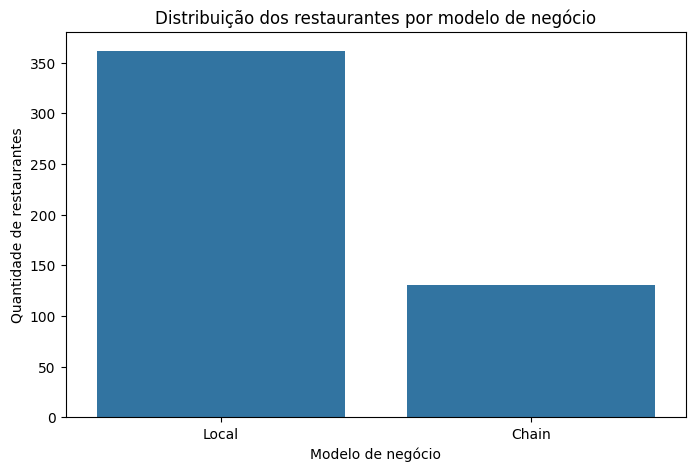

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=restaurants_sp,
    x='Chain_local'
)

plt.xlabel('Modelo de negócio')
plt.ylabel('Quantidade de restaurantes')
plt.title('Distribuição dos restaurantes por modelo de negócio')

plt.show()

# 9. Construção da base analítica

As informações dos diferentes datasets serão integradas utilizando `Restaurant_ID` como chave.

A base principal será formada pelas características dos restaurantes e complementada pelas informações disponíveis nos demais datasets.

A variável `Chain_local` será utilizada como principal variável de agrupamento para comparar restaurantes de rede e restaurantes locais.

In [9]:
analysis = restaurants_sp.copy()

analysis = analysis.merge(
    restaurant_features,
    on='Restaurant_ID',
    how='left'
)

analysis = analysis.merge(
    restaurant_statistics,
    on='Restaurant_ID',
    how='left'
)

analysis = analysis.merge(
    delivery_metrics,
    on='Restaurant_ID',
    how='left'
)

print('Dimensões da base analítica:', analysis.shape)

display(analysis.head())

Dimensões da base analítica: (493, 44)


,Restaurant_ID,Restaurant_name,Chain_local,Cuisine,Latitude,Longitude,City,Country,Opening_year,Delivery_available,...,Estimated_value_score,Delivery_fee,Service_fee,Packaging_fee,Estimated_delivery_time,Average_delivery_time_y,Peak_hour_multiplier,Minimum_order,Cancellation_rate,Availability
0,RES000006,Sao Paulo Brazilian Place 6,Local,Brazilian,40.445061,60.883749,Sao Paulo,Brazil,2023,True,...,1.6,2.56,1.85,1.79,37.0,46.0,2.50,5.89,0.065,True
1,RES000009,Sao Paulo American Place 9,Local,American,72.664066,-102.051267,Sao Paulo,Brazil,1994,True,...,4.0,1.53,3.26,0.69,28.0,38.0,1.20,23.60,0.020,True
2,RES000014,Sao Paulo Italian Place 14,Local,Italian,72.756401,100.157030,Sao Paulo,Brazil,2005,False,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RES000033,Sao Paulo Brazilian Place 33,Local,Brazilian,-63.710917,-162.204457,Sao Paulo,Brazil,2002,True,...,4.5,6.97,3.91,1.53,81.0,80.0,1.65,7.26,0.009,False
4,RES000034,Sao Paulo French Place 34,Local,French,57.908244,-50.719090,Sao Paulo,Brazil,1992,True,...,8.2,7.30,2.61,0.10,27.0,22.0,2.34,23.75,0.015,True


# 10. Verificação dos grupos

Após a integração dos datasets, será verificado se a variável `Chain_local` permanece disponível e se existem valores ausentes.

Essa verificação é importante porque o modelo de negócio será utilizado como variável principal nas análises comparativas.

In [10]:
print(analysis['Chain_local'].value_counts(dropna=False))

print('\nValores ausentes:')
print(analysis['Chain_local'].isna().sum())

Chain_local
Local    362
Chain    131
Name: count, dtype: int64

Valores ausentes:
0


# 11. Perfil geral da amostra

Antes de comparar os modelos de negócio, será realizado um resumo das principais características dos restaurantes analisados.

Serão observadas variáveis relacionadas a:

- avaliação;
- preço;
- preço médio do menu;
- popularidade;
- percepção de valor;
- tempo de entrega;
- cancelamento;
- custos de delivery.

In [19]:
variables = [
    'Average_rating',
    'Price_level',
    'Average_menu_price',
    'Popularity_score',
    'Estimated_value_score',
    'Estimated_delivery_time',
    'Average_delivery_time_y',
    'Cancellation_rate',
    'Delivery_fee',
    'Service_fee',
    'Packaging_fee'
]

profile = (
    analysis[variables]
    .describe()
    .T
)

profile.index = [
    'Avaliação média',
    'Nível de preço',
    'Preço médio do menu',
    'Índice de popularidade',
    'Índice de percepção de valor',
    'Tempo estimado de entrega',
    'Tempo médio de entrega',
    'Taxa de cancelamento',
    'Taxa de entrega',
    'Taxa de serviço',
    'Taxa de embalagem'
]

display(profile.round(2))

,count,mean,std,min,25%,50%,75%,max
Avaliação média,493.0,3.42,0.88,2.00,2.70,3.30,4.20,5.00
Nível de preço,493.0,2.41,1.10,1.00,1.00,2.00,3.00,4.00
Preço médio do menu,493.0,54.66,26.02,13.69,29.53,50.22,76.37,115.20
Índice de popularidade,493.0,49.05,27.68,0.10,25.80,47.90,73.90,99.90
Índice de percepção de valor,493.0,5.10,2.87,0.00,2.60,5.00,7.70,10.00
Tempo estimado de entrega,305.0,53.90,22.31,15.00,35.00,54.00,73.00,90.00
Tempo médio de entrega,305.0,57.00,22.80,13.00,38.00,56.00,77.00,100.00
Taxa de cancelamento,305.0,0.05,0.03,0.00,0.02,0.04,0.07,0.10
Taxa de entrega,305.0,5.16,2.81,0.05,2.73,5.19,7.68,10.00
Taxa de serviço,305.0,2.53,1.41,0.03,1.39,2.49,3.75,4.98


# 12. Comparação entre modelos de negócio

Nesta etapa serão comparadas as principais métricas entre restaurantes locais e restaurantes de rede.

A análise começará com estatísticas descritivas para identificar diferenças de:

- média;
- mediana;
- dispersão;
- tamanho da amostra.

A comparação de médias isoladamente não será suficiente para determinar se existe uma diferença estatisticamente relevante.

In [26]:
comparison_variables = [
    'Average_rating',
    'Price_level',
    'Average_menu_price',
    'Popularity_score',
    'Estimated_value_score',
    'Estimated_delivery_time',
    'Average_delivery_time_y',
    'Cancellation_rate',
    'Delivery_fee',
    'Service_fee',
    'Packaging_fee'
]

comparison = (
    analysis
    .groupby('Chain_local')[comparison_variables]
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

translation = {
    'Average_rating': 'Avaliação média',
    'Price_level': 'Nível de preço',
    'Average_menu_price': 'Preço médio do menu',
    'Popularity_score': 'Índice de popularidade',
    'Estimated_value_score': 'Índice de percepção de valor',
    'Estimated_delivery_time': 'Tempo estimado de entrega',
    'Average_delivery_time_y': 'Tempo médio de entrega',
    'Cancellation_rate': 'Taxa de cancelamento',
    'Delivery_fee': 'Taxa de entrega',
    'Service_fee': 'Taxa de serviço',
    'Packaging_fee': 'Taxa de embalagem'
}

comparison = comparison.rename(columns=translation, level=0)

display(comparison)

Avaliação média                    Nível de preço               \
                      count  mean median   std          count  mean median   
Chain_local                                                                  
Chain                   131  3.42    3.3  0.90            131  2.44    2.0   
Local                   362  3.42    3.3  0.88            362  2.41    2.0   

                  Preço médio do menu         ... Taxa de entrega        \
              std               count   mean  ...          median   std   
Chain_local                                   ...                         
Chain        1.17                 131  54.81  ...            5.44  2.73   
Local        1.07                 362  54.60  ...            4.99  2.83   

            Taxa de serviço                    Taxa de embalagem               \
                      count  mean median   std             count  mean median   
Chain_local                                                                     
Chain                    80  2.72   2.84  1.32                80  1.04   1.00   
Local                   225  2.47   2.34  1.43               225  0.96   0.89   

                   
              std  
Chain_local        
Chain        0.58  
Local        0.58  

[2 rows x 44 columns]

# 13. H1 — Modelo de negócio e preço

### Pergunta

> Restaurantes de rede e restaurantes locais apresentam diferenças no nível de preço?

A análise será realizada utilizando o `Price_level` e, adicionalmente, o preço médio do menu.

A comparação será feita inicialmente por meio de estatísticas descritivas e visualização da distribuição dos grupos.

Posteriormente, será realizado um teste estatístico para avaliar se a diferença observada é compatível com uma diferença populacional ou pode ser explicada pela variação amostral.

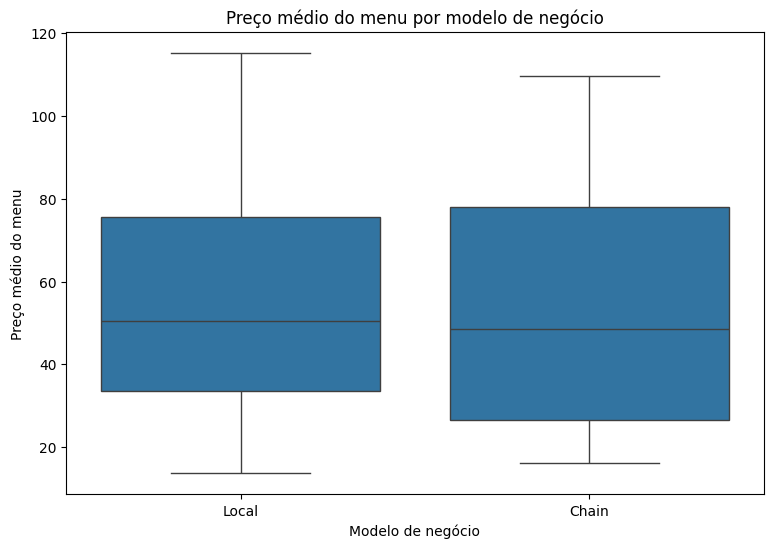

In [13]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Average_menu_price'
)

plt.xlabel('Modelo de negócio')
plt.ylabel('Preço médio do menu')
plt.title('Preço médio do menu por modelo de negócio')

plt.show()

In [14]:
price_data = analysis[
    ['Chain_local', 'Average_menu_price']
].dropna()

chain_price = price_data.loc[
    price_data['Chain_local'] == 'Chain',
    'Average_menu_price'
]

local_price = price_data.loc[
    price_data['Chain_local'] == 'Local',
    'Average_menu_price'
]

test_price = stats.ttest_ind(
    chain_price,
    local_price,
    equal_var=False
)

print(f'Média - Rede: {chain_price.mean():.2f}')
print(f'Média - Local: {local_price.mean():.2f}')
print(f'Diferença: {chain_price.mean() - local_price.mean():.2f}')
print(f'p-valor: {test_price.pvalue:.4f}')

Média - Rede: 54.81
Média - Local: 54.60
Diferença: 0.20
p-valor: 0.9401


# 14. H2 — Modelo de negócio e avaliação

### Pergunta

> Restaurantes de rede e restaurantes locais apresentam diferenças na avaliação média?

A variável analisada será `Average_rating`.

A comparação será realizada considerando tanto a média quanto a distribuição das avaliações.

Isso evita que a análise dependa exclusivamente de uma medida de tendência central.

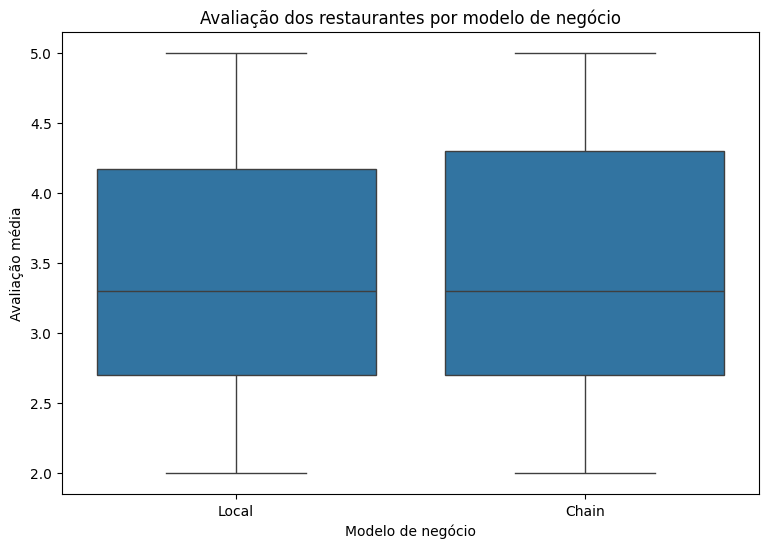

In [15]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Average_rating'
)

plt.xlabel('Modelo de negócio')
plt.ylabel('Avaliação média')
plt.title('Avaliação dos restaurantes por modelo de negócio')

plt.show()

In [16]:
rating_data = analysis[
    ['Chain_local', 'Average_rating']
].dropna()

chain_rating = rating_data.loc[
    rating_data['Chain_local'] == 'Chain',
    'Average_rating'
]

local_rating = rating_data.loc[
    rating_data['Chain_local'] == 'Local',
    'Average_rating'
]

test_rating = stats.ttest_ind(
    chain_rating,
    local_rating,
    equal_var=False
)

print(f'Média - Rede: {chain_rating.mean():.3f}')
print(f'Média - Local: {local_rating.mean():.3f}')
print(f'Diferença: {chain_rating.mean() - local_rating.mean():.3f}')
print(f'p-valor: {test_rating.pvalue:.4f}')

Média - Rede: 3.416
Média - Local: 3.418
Diferença: -0.002
p-valor: 0.9856


# 15. H3 — Modelo de negócio e popularidade

### Pergunta

> Restaurantes de rede apresentam níveis diferentes de popularidade em relação aos restaurantes locais?

A popularidade será analisada utilizando `Popularity_score`.

A hipótese é relevante porque restaurantes pertencentes a redes podem apresentar características diferentes de escala, reconhecimento de marca e presença no mercado.

Entretanto, essas possibilidades serão tratadas como hipóteses e não como conclusões prévias.

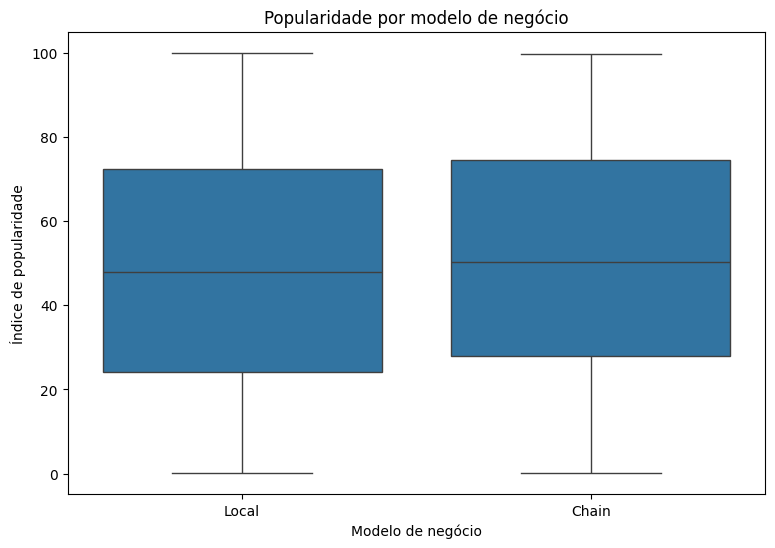

In [17]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Popularity_score'
)

plt.xlabel('Modelo de negócio')
plt.ylabel('Índice de popularidade')
plt.title('Popularidade por modelo de negócio')

plt.show()

In [18]:
popularity_data = analysis[
    ['Chain_local', 'Popularity_score']
].dropna()

chain_popularity = popularity_data.loc[
    popularity_data['Chain_local'] == 'Chain',
    'Popularity_score'
]

local_popularity = popularity_data.loc[
    popularity_data['Chain_local'] == 'Local',
    'Popularity_score'
]

test_popularity = stats.ttest_ind(
    chain_popularity,
    local_popularity,
    equal_var=False
)

print(f'Média - Rede: {chain_popularity.mean():.2f}')
print(f'Média - Local: {local_popularity.mean():.2f}')
print(f'Diferença: {chain_popularity.mean() - local_popularity.mean():.2f}')
print(f'p-valor: {test_popularity.pvalue:.4f}')

Média - Rede: 49.70
Média - Local: 48.82
Diferença: 0.88
p-valor: 0.7560


# 16. H4 — Modelo de negócio e percepção de valor

### Pergunta

> Restaurantes de rede e restaurantes locais apresentam diferenças na percepção de valor?

Será utilizada a variável `Estimated_value_score`.

Essa análise busca verificar se os dois modelos de negócio apresentam diferenças na percepção de valor atribuída aos restaurantes na base.

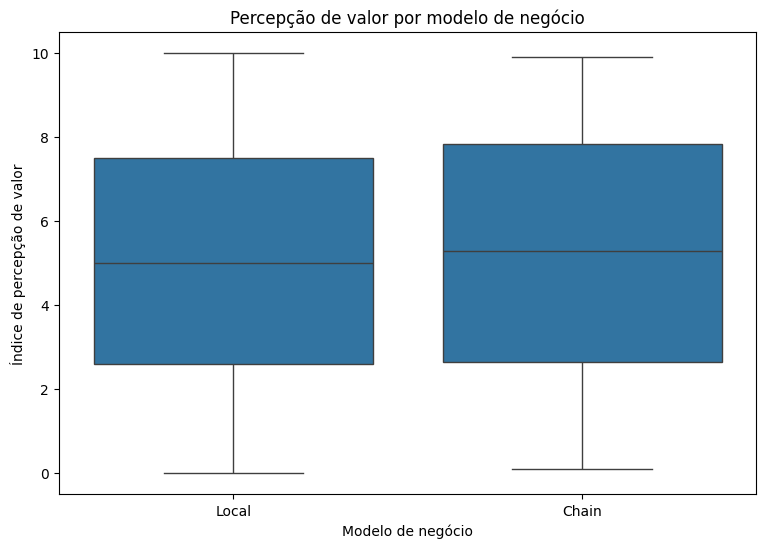

In [27]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Estimated_value_score'
)

plt.xlabel('Modelo de negócio')
plt.ylabel('Índice de percepção de valor')
plt.title('Percepção de valor por modelo de negócio')

plt.show()

In [28]:
value_data = analysis[
    ['Chain_local', 'Estimated_value_score']
].dropna()

chain_value = value_data.loc[
    value_data['Chain_local'] == 'Chain',
    'Estimated_value_score'
]

local_value = value_data.loc[
    value_data['Chain_local'] == 'Local',
    'Estimated_value_score'
]

test_value = stats.ttest_ind(
    chain_value,
    local_value,
    equal_var=False
)

print(f'Média - Rede: {chain_value.mean():.2f}')
print(f'Média - Local: {local_value.mean():.2f}')
print(f'Diferença: {chain_value.mean() - local_value.mean():.2f}')
print(f'p-valor: {test_value.pvalue:.4f}')

Média - Rede: 5.18
Média - Local: 5.07
Diferença: 0.11
p-valor: 0.7191


# 17. Modelo de negócio e operação de delivery

Além das características comerciais, será analisado se restaurantes de rede e restaurantes locais apresentam diferenças na operação de delivery.

Serão avaliadas:

- disponibilidade do delivery;
- tempo estimado;
- tempo médio real;
- atraso;
- taxa de cancelamento;
- taxa de entrega;
- taxa de serviço;
- taxa de embalagem.

A análise permitirá verificar se as diferenças entre os modelos de negócio também aparecem na operação de entrega.

In [39]:
analysis['Atraso_entrega'] = (
    analysis['Average_delivery_time_y']
    - analysis['Estimated_delivery_time']
)

atraso_entrega = analysis[
    [
        'Restaurant_ID',
        'Estimated_delivery_time',
        'Average_delivery_time_y',
        'Atraso_entrega'
    ]
].head(10).rename(columns={
    'Restaurant_ID': 'ID do restaurante',
    'Estimated_delivery_time': 'Tempo estimado de entrega (min)',
    'Average_delivery_time_y': 'Tempo médio de entrega (min)',
    'Atraso_entrega': 'Atraso na entrega (min)'
})

display(atraso_entrega)

,ID do restaurante,Tempo estimado de entrega (min),Tempo médio de entrega (min),Atraso na entrega (min)
0,RES000006,37.0,46.0,9.0
1,RES000009,28.0,38.0,10.0
2,RES000014,NaN,NaN,NaN
3,RES000033,81.0,80.0,-1.0
4,RES000034,27.0,22.0,-5.0
5,RES000039,NaN,NaN,NaN
6,RES000073,67.0,69.0,2.0
7,RES000082,48.0,57.0,9.0
8,RES000109,NaN,NaN,NaN
9,RES000135,89.0,88.0,-1.0


In [40]:
analysis['Custo_total_delivery'] = (
    analysis['Delivery_fee']
    + analysis['Service_fee']
    + analysis['Packaging_fee']
)

custo_delivery = analysis[
    [
        'Restaurant_ID',
        'Delivery_fee',
        'Service_fee',
        'Packaging_fee',
        'Custo_total_delivery'
    ]
].head().rename(columns={
    'Restaurant_ID': 'ID do restaurante',
    'Delivery_fee': 'Taxa de entrega',
    'Service_fee': 'Taxa de serviço',
    'Packaging_fee': 'Taxa de embalagem',
    'Custo_total_delivery': 'Custo total do delivery'
})

display(custo_delivery)

,ID do restaurante,Taxa de entrega,Taxa de serviço,Taxa de embalagem,Custo total do delivery
0,RES000006,2.56,1.85,1.79,6.20
1,RES000009,1.53,3.26,0.69,5.48
2,RES000014,NaN,NaN,NaN,NaN
3,RES000033,6.97,3.91,1.53,12.41
4,RES000034,7.30,2.61,0.10,10.01


# 18. Comparação operacional do delivery

Serão comparados os principais indicadores operacionais de delivery entre restaurantes de rede e restaurantes locais.

A análise não considera apenas se existe uma diferença entre as médias, mas também a distribuição dos valores dentro de cada grupo.

Isso permite identificar se uma eventual diferença é consistente ou se resulta de alguns poucos restaurantes com valores extremos.

In [33]:
delivery_variables = [
    'Estimated_delivery_time',
    'Average_delivery_time_y',
    'Atraso_entrega',
    'Cancellation_rate',
    'Delivery_fee',
    'Service_fee',
    'Packaging_fee',
    'Custo_total_delivery'
]

delivery_comparison = (
    analysis
    .groupby('Chain_local')[delivery_variables]
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

delivery_translation = {
    'Estimated_delivery_time': 'Tempo estimado de entrega',
    'Average_delivery_time_y': 'Tempo médio de entrega',
    'Atraso_entrega': 'Atraso na entrega',
    'Cancellation_rate': 'Taxa de cancelamento',
    'Delivery_fee': 'Taxa de entrega',
    'Service_fee': 'Taxa de serviço',
    'Packaging_fee': 'Taxa de embalagem',
    'Custo_total_delivery': 'Custo total do delivery'
}

group_translation = {
    'Chain': 'Rede',
    'Local': 'Local'
}

delivery_comparison = delivery_comparison.rename(
    columns=delivery_translation,
    level=0
)

delivery_comparison = delivery_comparison.rename(
    columns={
        'count': 'Quantidade',
        'mean': 'Média',
        'median': 'Mediana',
        'std': 'Desvio padrão'
    },
    level=1
)

delivery_comparison.index = delivery_comparison.index.map(
    lambda x: group_translation.get(x, x)
)

display(delivery_comparison)

Tempo estimado de entrega                               \
                           Quantidade  Média Mediana Desvio padrão   
Chain_local                                                          
Rede                               80  56.79    54.0         21.12   
Local                             225  52.88    53.0         22.68   

            Tempo médio de entrega                               \
                        Quantidade  Média Mediana Desvio padrão   
Chain_local                                                       
Rede                            80  60.41    58.0         20.98   
Local                          225  55.79    55.0         23.34   

            Atraso na entrega        ... Taxa de serviço                \
                   Quantidade Média  ...         Mediana Desvio padrão   
Chain_local                          ...                                 
Rede                       80  3.62  ...            2.84          1.32   
Local                     225  2.92  ...            2.34          1.43   

            Taxa de embalagem                              \
                   Quantidade Média Mediana Desvio padrão   
Chain_local                                                 
Rede                       80  1.04    1.00          0.58   
Local                     225  0.96    0.89          0.58   

            Custo total do delivery                              
                         Quantidade Média Mediana Desvio padrão  
Chain_local                                                      
Rede                             80  9.31    9.18          2.74  
Local                           225  8.45    8.20          3.19  

[2 rows x 32 columns]

## Distribuição dos indicadores de delivery

Os gráficos abaixo permitem comparar visualmente o comportamento dos principais indicadores operacionais entre restaurantes de rede e restaurantes locais.

---



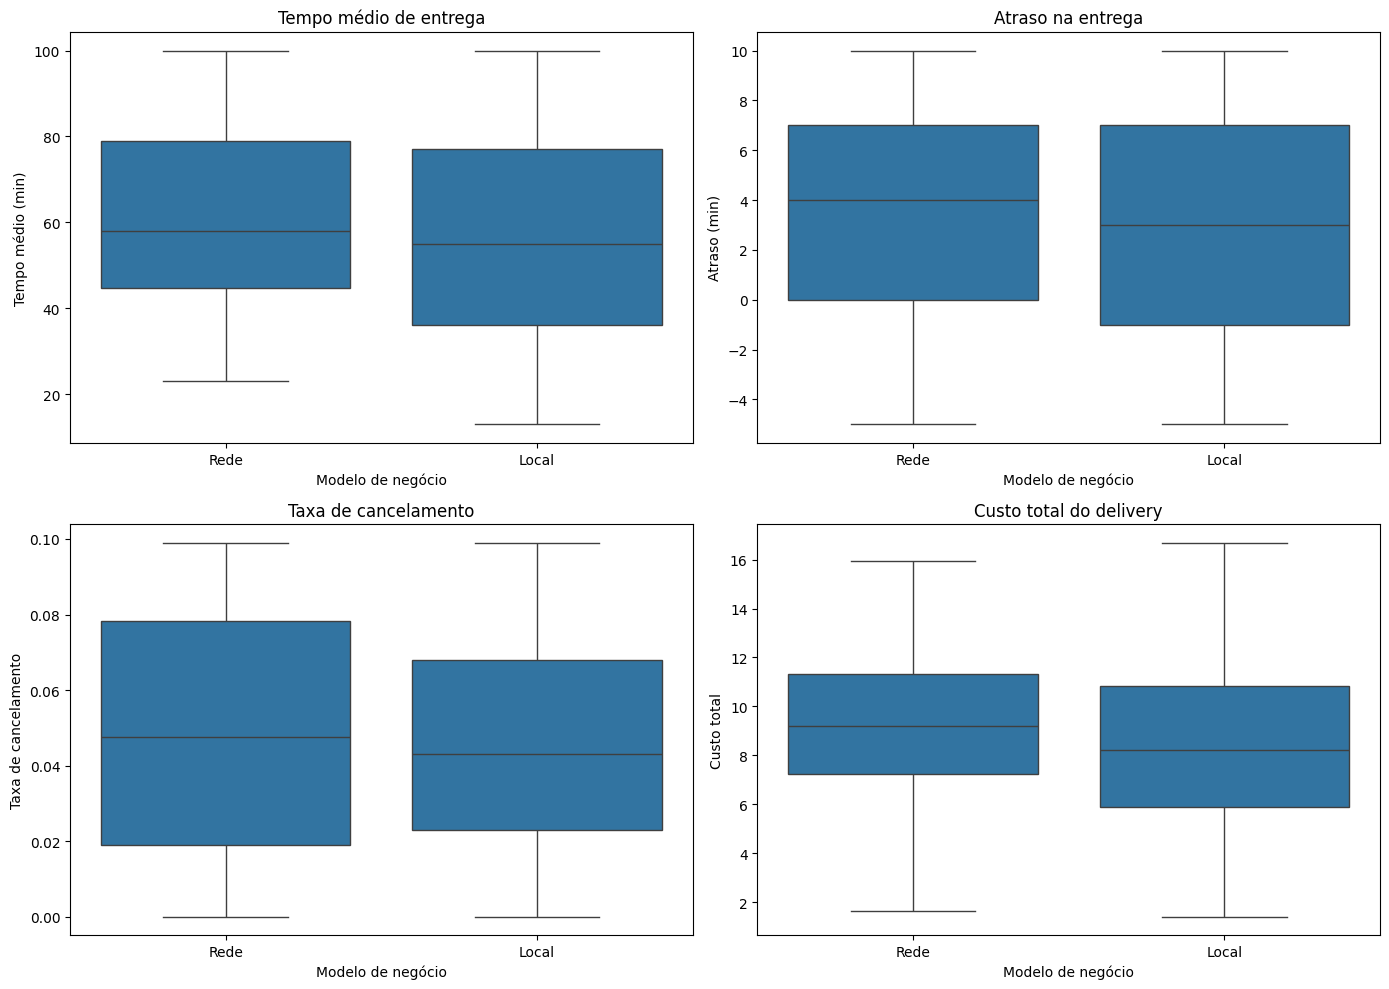

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ordem_modelo = ['Chain', 'Local']
rotulos_modelo = ['Rede', 'Local']

sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Average_delivery_time_y',
    order=ordem_modelo,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Tempo médio de entrega')
axes[0, 0].set_xlabel('Modelo de negócio')
axes[0, 0].set_ylabel('Tempo médio (min)')
axes[0, 0].set_xticks(range(2))
axes[0, 0].set_xticklabels(rotulos_modelo)


sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Atraso_entrega',
    order=ordem_modelo,
    ax=axes[0, 1]
)

axes[0, 1].set_title('Atraso na entrega')
axes[0, 1].set_xlabel('Modelo de negócio')
axes[0, 1].set_ylabel('Atraso (min)')
axes[0, 1].set_xticks(range(2))
axes[0, 1].set_xticklabels(rotulos_modelo)


sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Cancellation_rate',
    order=ordem_modelo,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Taxa de cancelamento')
axes[1, 0].set_xlabel('Modelo de negócio')
axes[1, 0].set_ylabel('Taxa de cancelamento')
axes[1, 0].set_xticks(range(2))
axes[1, 0].set_xticklabels(rotulos_modelo)


sns.boxplot(
    data=analysis,
    x='Chain_local',
    y='Custo_total_delivery',
    order=ordem_modelo,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Custo total do delivery')
axes[1, 1].set_xlabel('Modelo de negócio')
axes[1, 1].set_ylabel('Custo total')
axes[1, 1].set_xticks(range(2))
axes[1, 1].set_xticklabels(rotulos_modelo)


plt.tight_layout()
plt.show()

# 19. Testes estatísticos — Delivery

As diferenças observadas nos indicadores de delivery serão avaliadas estatisticamente.

Será utilizado o **teste t de Welch**, que não pressupõe variâncias iguais entre os grupos.

O objetivo é verificar se as diferenças médias observadas entre restaurantes de rede e restaurantes locais são estatisticamente compatíveis com uma diferença entre os grupos.

Além do p-valor, serão observadas as diferenças de magnitude entre as médias.

In [35]:
def comparar_grupos(df, variavel):

    dados = df[['Chain_local', variavel]].dropna()

    rede = dados.loc[
        dados['Chain_local'] == 'Chain',
        variavel
    ]

    local = dados.loc[
        dados['Chain_local'] == 'Local',
        variavel
    ]

    teste = stats.ttest_ind(
        rede,
        local,
        equal_var=False
    )

    resultado = {
        'Variável': variavel,
        'Média rede': rede.mean(),
        'Média local': local.mean(),
        'Diferença': rede.mean() - local.mean(),
        'p-valor': teste.pvalue,
        'N rede': len(rede),
        'N local': len(local)
    }

    return resultado


resultados_delivery = pd.DataFrame([
    comparar_grupos(analysis, var)
    for var in delivery_variables
])

resultados_delivery['Variável'] = resultados_delivery['Variável'].replace({
    'Estimated_delivery_time': 'Tempo estimado de entrega',
    'Average_delivery_time_y': 'Tempo médio de entrega',
    'Atraso_entrega': 'Atraso na entrega',
    'Cancellation_rate': 'Taxa de cancelamento',
    'Delivery_fee': 'Taxa de entrega',
    'Service_fee': 'Taxa de serviço',
    'Packaging_fee': 'Taxa de embalagem',
    'Custo_total_delivery': 'Custo total do delivery'
})

resultados_delivery = resultados_delivery.rename(columns={
    'Média rede': 'Média - Rede',
    'Média local': 'Média - Local',
    'Diferença': 'Diferença entre médias',
    'p-valor': 'p-valor',
    'N rede': 'N - Rede',
    'N local': 'N - Local'
})

display(resultados_delivery.round(4))

,Variável,Média - Rede,Média - Local,Diferença entre médias,p-valor,N - Rede,N - Local
0,Tempo estimado de entrega,56.7875,52.8756,3.9119,0.1651,80,225
1,Tempo médio de entrega,60.4125,55.7911,4.6214,0.1026,80,225
2,Atraso na entrega,3.6250,2.9156,0.7094,0.2095,80,225
3,Taxa de cancelamento,0.0487,0.0450,0.0037,0.3502,80,225
4,Taxa de entrega,5.5576,5.0160,0.5416,0.1337,80,225
5,Taxa de serviço,2.7177,2.4668,0.2510,0.1559,80,225
6,Taxa de embalagem,1.0365,0.9628,0.0737,0.3280,80,225
7,Custo total do delivery,9.3119,8.4456,0.8663,0.0214,80,225


# 20. Modelo multivariado

As análises anteriores comparam restaurantes de rede e restaurantes locais individualmente.

Entretanto, diferenças observadas entre os grupos podem estar relacionadas a outras características.

Por exemplo, restaurantes de rede podem apresentar preços, popularidade ou características operacionais diferentes.

Para investigar essa questão, será estimado um modelo de regressão linear múltipla.

### Variável dependente

A variável dependente será:

`Average_rating` — **Avaliação média**

### Variável principal de interesse

`Chain_local` — **Modelo de negócio**

### Variáveis de controle

- `Price_level` — nível de preço;
- `Average_menu_price` — preço médio do menu;
- `Popularity_score` — índice de popularidade;
- `Estimated_value_score` — índice de percepção de valor;
- `Average_delivery_time_y` — tempo médio de entrega;
- `Cancellation_rate` — taxa de cancelamento;
- `Custo_total_delivery` — custo total do delivery.

O objetivo será verificar se o modelo de negócio permanece associado à avaliação depois de considerar simultaneamente outras características observadas.

In [36]:
model_data = analysis[
    [
        'Average_rating',
        'Chain_local',
        'Price_level',
        'Average_menu_price',
        'Popularity_score',
        'Estimated_value_score',
        'Average_delivery_time_y',
        'Cancellation_rate',
        'Custo_total_delivery'
    ]
].dropna()

model = smf.ols(
    '''
    Average_rating ~
    C(Chain_local) +
    Price_level +
    Average_menu_price +
    Popularity_score +
    Estimated_value_score +
    Average_delivery_time_y +
    Cancellation_rate +
    Custo_total_delivery
    ''',
    data=model_data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Average_rating   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.517
Date:                Sat, 15 Aug 2026   Prob (F-statistic):              0.151
Time:                        18:22:55   Log-Likelihood:                -385.58
No. Observations:                 305   AIC:                             789.2
Df Residuals:                     296   BIC:                             822.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# 21. Resultados do modelo multivariado

Para facilitar a interpretação, os principais resultados da regressão serão apresentados em uma tabela simplificada contendo:

- variável;
- coeficiente;
- p-valor;
- intervalo de confiança.

O coeficiente associado ao modelo de negócio representa a diferença estimada entre restaurantes de rede e restaurantes locais, mantendo as demais variáveis do modelo constantes.

In [37]:
results = pd.DataFrame({
    'Variável': model.params.index,
    'Coeficiente': model.params.values,
    'P-valor': model.pvalues.values,
    'IC inferior': model.conf_int()[0].values,
    'IC superior': model.conf_int()[1].values
})

results['Variável'] = results['Variável'].replace({
    'Intercept': 'Intercepto',
    'C(Chain_local)[T.Local]': 'Restaurante local',
    'Price_level': 'Nível de preço',
    'Average_menu_price': 'Preço médio do menu',
    'Popularity_score': 'Índice de popularidade',
    'Estimated_value_score': 'Índice de percepção de valor',
    'Average_delivery_time_y': 'Tempo médio de entrega',
    'Cancellation_rate': 'Taxa de cancelamento',
    'Custo_total_delivery': 'Custo total do delivery'
})

display(results.round(4))

,Variável,Coeficiente,P-valor,IC inferior,IC superior
0,Intercepto,3.4930,0.0000,2.8762,4.1098
1,Restaurante local,-0.1055,0.3590,-0.3315,0.1205
2,Nível de preço,-0.0369,0.7990,-0.3221,0.2482
3,Preço médio do menu,-0.0019,0.7616,-0.0140,0.0103
4,Índice de popularidade,-0.0022,0.2305,-0.0057,0.0014
5,Índice de percepção de valor,0.0268,0.1364,-0.0085,0.0622
6,Tempo médio de entrega,0.0035,0.1226,-0.0009,0.0078
7,Taxa de cancelamento,1.9844,0.2681,-1.5351,5.5040
8,Custo total do delivery,-0.0136,0.4066,-0.0457,0.0186


# 22. Diagnóstico de multicolinearidade

Antes de interpretar os coeficientes individuais do modelo, será avaliada a existência de multicolinearidade entre as variáveis explicativas.

A multicolinearidade ocorre quando variáveis explicativas apresentam forte relação linear entre si.

Será utilizado o **Variance Inflation Factor (VIF)**, ou **Fator de Inflação da Variância**.

De forma geral:

- **VIF próximo de 1** → pouca ou nenhuma multicolinearidade;
- **VIF entre 1 e 5** → nível geralmente aceitável;
- **VIF acima de 5** → possível problema;
- **VIF acima de 10** → forte indicação de multicolinearidade.

O intercepto não será utilizado para avaliar a multicolinearidade das variáveis explicativas.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = model_data[
    [
        'Price_level',
        'Average_menu_price',
        'Popularity_score',
        'Estimated_value_score',
        'Average_delivery_time_y',
        'Cancellation_rate',
        'Custo_total_delivery'
    ]
].copy()

X = sm.add_constant(X)

vif = pd.DataFrame()

vif['Variável'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif['Variável'] = vif['Variável'].replace({
    'const': 'Intercepto',
    'Price_level': 'Nível de preço',
    'Average_menu_price': 'Preço médio do menu',
    'Popularity_score': 'Índice de popularidade',
    'Estimated_value_score': 'Índice de percepção de valor',
    'Average_delivery_time_y': 'Tempo médio de entrega',
    'Cancellation_rate': 'Taxa de cancelamento',
    'Custo_total_delivery': 'Custo total do delivery'
})

display(vif.round(2))

,Variável,VIF
0,Intercepto,33.81
1,Nível de preço,10.28
2,Preço médio do menu,10.27
3,Índice de popularidade,1.01
4,Índice de percepção de valor,1.04
5,Tempo médio de entrega,1.03
6,Taxa de cancelamento,1.01
7,Custo total do delivery,1.01


# 23. Síntese das hipóteses

Ao final das análises, as hipóteses foram avaliadas com base nos seguintes critérios:

- diferença observada entre os grupos;
- magnitude da diferença;
- p-valor;
- intervalo de confiança;
- consistência entre as análises descritivas, visuais e estatísticas;
- resultados do modelo multivariado.

| Hipótese | Resultado | Evidência |
|---|---|---|
| **H1 — Modelo de negócio × preço** | **Não apoiada** | Não foram identificadas diferenças estatisticamente significativas entre restaurantes de rede e locais nos indicadores de preço analisados. |
| **H2 — Modelo de negócio × avaliação** | **Não apoiada** | Não foram identificadas diferenças estatisticamente significativas nas avaliações entre restaurantes de rede e locais. |
| **H3 — Modelo de negócio × popularidade** | **Não apoiada** | Não foram identificadas diferenças estatisticamente significativas nos indicadores de popularidade entre os grupos. |
| **H4 — Modelo de negócio × percepção de valor** | **Não apoiada** | Não foram identificadas diferenças estatisticamente significativas na percepção de valor entre restaurantes de rede e locais. |
| **H5 — Modelo de negócio × delivery** | **Parcialmente apoiada** | O custo total do delivery apresentou diferença estatisticamente significativa entre os grupos (Rede = 9,31; Local = 8,45; diferença = 0,87; p = 0,0214). Os demais indicadores de delivery não apresentaram diferenças estatisticamente significativas. |
| **H6 — Modelo de negócio × avaliação após controles** | **Não apoiada*** | No modelo multivariado, a variável Restaurante local não apresentou associação estatisticamente significativa com a variável dependente (β = -0,1055; p = 0,3590; IC95% = [-0,3315; 0,1205]). |

> A classificação das hipóteses foi realizada considerando o nível de significância de 5%. A H5 foi classificada como parcialmente apoiada porque apenas uma das dimensões de delivery analisadas — o custo total do delivery — apresentou diferença estatisticamente significativa entre restaurantes de rede e locais. A H6 foi classificada como não apoiada no modelo estimado, embora exista uma ressalva metodológica relacionada à multicolinearidade entre as variáveis Nível de preço e Preço médio do menu, ambas com VIF aproximadamente igual a 10,3. Recomenda-se interpretar o resultado da H6 com cautela e, se necessário, realizar uma análise de robustez retirando uma dessas variáveis do modelo.

# 24. Síntese dos resultados

Nesta etapa serão consolidados os principais resultados encontrados ao longo da análise.

O objetivo é transformar os resultados estatísticos em conclusões relacionadas às diferenças entre os modelos de negócio dos restaurantes.

A análise buscará responder:

- quais características diferenciam restaurantes de rede e restaurantes locais;
- em quais dimensões as diferenças são maiores;
- quais diferenças apresentam evidência estatística suficiente;
- quais diferenças permanecem após considerar outras características simultaneamente;
- quais dimensões não apresentam evidência suficiente de diferença entre os grupos.

Os resultados serão apresentados de forma objetiva, destacando tanto as diferenças encontradas quanto os resultados que não apresentaram evidência estatística suficiente.

> A ausência de evidência estatística suficiente para uma diferença também será considerada um resultado relevante para a análise.

# 25. Conclusões

## 1. Perfil dos modelos de negócio

A análise comparou restaurantes de rede e restaurantes locais, considerando a composição da amostra e as principais características dos estabelecimentos.

A amostra analisada foi composta por **80 restaurantes de rede e 225 restaurantes locais**, totalizando **305 observações**. Dessa forma, os restaurantes locais representam a maior parcela da amostra, enquanto os restaurantes de rede correspondem a uma parcela menor.

Essa diferença no tamanho dos grupos foi considerada na interpretação das análises estatísticas, uma vez que as comparações não foram realizadas entre grupos de tamanhos iguais.

## 2. Preço

Foi analisada a diferença no nível de preço e no preço médio do menu entre restaurantes de rede e restaurantes locais.

Os resultados das análises não apresentaram evidência estatística suficiente para afirmar que o modelo de negócio esteja associado a diferenças significativas nos indicadores de preço analisados.

Embora possam existir diferenças numéricas entre as médias dos grupos, essas diferenças não foram suficientes, considerando o nível de significância adotado, para sustentar a hipótese de que restaurantes de rede e restaurantes locais apresentam comportamentos distintos de preço na amostra.

Assim, a **H1 não foi apoiada pelos dados**.

## 3. Avaliação

Foi investigado se restaurantes de rede e restaurantes locais apresentam diferenças na avaliação média dos consumidores.

Os resultados não indicaram diferença estatisticamente significativa entre os grupos. Dessa forma, não foi encontrada evidência suficiente para afirmar que restaurantes de rede apresentem avaliações médias diferentes das observadas entre restaurantes locais.

Portanto, considerando os resultados obtidos, a **H2 não foi apoiada pelos dados**.

## 4. Popularidade

Foi analisada a relação entre o modelo de negócio e o índice de popularidade dos restaurantes.

Apesar das possíveis diferenças descritivas observadas entre os grupos, os testes estatísticos não apresentaram evidência suficiente de uma diferença estatisticamente significativa na popularidade entre restaurantes de rede e restaurantes locais.

Assim, os resultados não permitem afirmar que o fato de um restaurante pertencer a uma rede esteja associado, por si só, a um maior ou menor nível de popularidade na amostra analisada.

Dessa forma, a **H3 não foi apoiada pelos dados**.

## 5. Percepção de valor

Foi investigada a diferença na percepção de valor entre restaurantes de rede e restaurantes locais.

Os resultados não apresentaram evidência estatisticamente significativa de diferença entre os dois modelos de negócio.

Portanto, embora possam existir diferenças numéricas entre os grupos, não há evidência suficiente para afirmar que restaurantes de rede e restaurantes locais sejam percebidos de maneira significativamente diferente em relação ao valor oferecido.

Assim, a **H4 não foi apoiada pelos dados**.

## 6. Delivery

Foram comparados os principais indicadores relacionados à operação de delivery, incluindo tempo estimado de entrega, tempo médio de entrega, atraso, taxa de cancelamento, taxa de entrega, taxa de serviço, taxa de embalagem e custo total do delivery.

De forma geral, os restaurantes de rede apresentaram valores médios superiores aos restaurantes locais em todos os indicadores analisados. Entretanto, a maior parte dessas diferenças não foi estatisticamente significativa.

A principal exceção foi o **custo total do delivery**. Os restaurantes de rede apresentaram custo médio de **9,31**, enquanto os restaurantes locais apresentaram média de **8,45**, resultando em uma diferença de aproximadamente **0,87 unidade**, estatisticamente significativa (**p = 0,0214**).

Por outro lado, não foram encontradas diferenças estatisticamente significativas para tempo estimado de entrega, tempo médio de entrega, atraso, taxa de cancelamento, taxa de entrega, taxa de serviço ou taxa de embalagem.

Dessa forma, os resultados sugerem que a principal diferença entre os modelos de negócio na dimensão operacional do delivery está relacionada ao **custo total**, e não necessariamente ao desempenho dos demais indicadores analisados.

Assim, a **H5 foi parcialmente apoiada pelos dados**.

## 7. Modelo multivariado

A regressão linear múltipla foi utilizada para verificar se o modelo de negócio permanece associado à avaliação média após considerar simultaneamente outras características observadas.

No modelo estimado, a variável **Restaurante local** apresentou coeficiente de **-0,1055**, com **p = 0,3590** e intervalo de confiança de 95% entre **-0,3315 e 0,1205**.

Como o p-valor foi superior a 0,05 e o intervalo de confiança inclui zero, não foi encontrada evidência estatisticamente significativa de associação entre o modelo de negócio e a variável dependente após o controle pelas demais variáveis incluídas no modelo.

Dessa forma, os resultados do modelo multivariado não sustentam a hipótese de que o modelo de negócio, isoladamente, esteja associado à avaliação após o controle por outras características dos restaurantes.

Assim, a **H6 não foi apoiada pelos dados**.

Entretanto, o diagnóstico de multicolinearidade revelou **VIF de 10,28 para Nível de preço e 10,27 para Preço médio do menu**, indicando forte sobreposição entre essas duas variáveis. Esse resultado constitui uma limitação metodológica do modelo e recomenda cautela na interpretação dos coeficientes individuais dessas variáveis. Uma análise de robustez, retirando uma das duas variáveis de preço, pode ser utilizada para verificar a estabilidade dos resultados.

---

## Considerações finais

Este estudo investigou diferenças entre restaurantes de rede e restaurantes locais, considerando características comerciais, percepção dos consumidores e indicadores operacionais de delivery.

De maneira geral, os resultados indicam que **o modelo de negócio apresentou poucas diferenças estatisticamente significativas entre os grupos**. As hipóteses relacionadas a preço, avaliação, popularidade e percepção de valor não foram apoiadas pelos testes realizados.

A principal evidência estatística encontrada esteve relacionada ao **custo total do delivery**, que apresentou valor médio superior entre restaurantes de rede em comparação aos restaurantes locais. Entretanto, os demais indicadores operacionais de delivery não apresentaram diferenças estatisticamente significativas. Por esse motivo, a hipótese relacionada ao delivery foi classificada como **parcialmente apoiada**.

O modelo multivariado reforçou a ausência de evidência estatística de uma associação entre o modelo de negócio e a avaliação após o controle pelas demais características incluídas na análise. Entretanto, a presença de multicolinearidade entre nível de preço e preço médio do menu representa uma limitação que deve ser considerada na interpretação desse resultado.

Em conjunto, os resultados sugerem que **ser um restaurante de rede ou local não está, de forma geral, associado a diferenças estatisticamente significativas nas dimensões analisadas**. A exceção identificada foi o custo total do delivery, no qual os restaurantes de rede apresentaram valores médios superiores.

É importante destacar que os resultados representam **associações observadas na amostra**, e não evidências de causalidade. A análise não permite afirmar que o modelo de negócio seja a causa direta das diferenças encontradas, uma vez que outros fatores observados e não observados podem influenciar os resultados.

Além disso, a amostra apresenta tamanhos diferentes entre os grupos, com maior número de restaurantes locais, o que deve ser considerado na interpretação dos resultados. A análise também está sujeita às limitações das variáveis disponíveis e da forma como os indicadores foram construídos.

Ainda assim, a comparação entre os grupos permite identificar padrões relevantes sobre diferentes modelos de operação no mercado de restaurantes e evidencia que as diferenças entre redes e estabelecimentos locais podem ser mais específicas e pontuais do que generalizadas.

Os resultados podem servir como ponto de partida para análises futuras utilizando dados temporais, informações no nível do pedido, amostras mais equilibradas entre os grupos e outras variáveis relacionadas ao comportamento dos consumidores e à operação dos restaurantes.